In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# LOAD DATA

In [3]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# EDA

### Check missing value

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Survival by gender

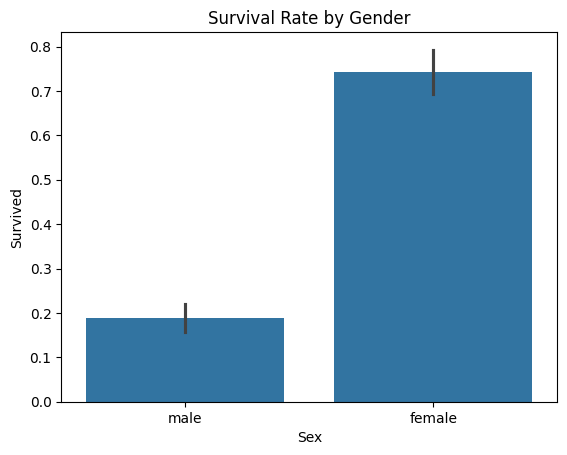

In [5]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()

### Survival by Pclass

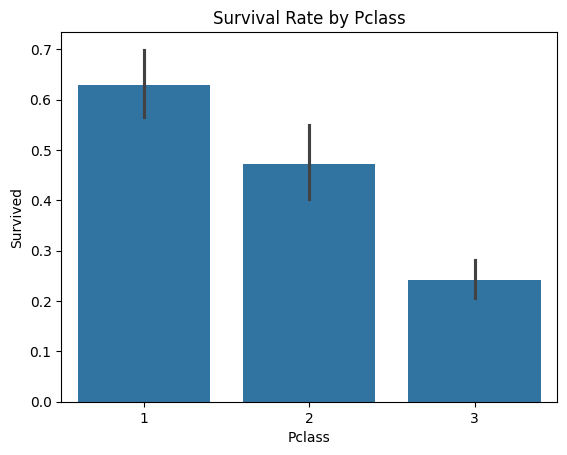

In [6]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Pclass')
plt.show()

# PREPROCESSING & FEATURE ENGINEERING

### Fill missing values

In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

### Feauture Engineering

In [10]:
# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Title
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Simplify
df['Title'] = df['Title'].replace([
    'Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'
], 'Rare')

df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})

# Simplify title
df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],'Rare')
df['Title'] = df['Title'].replace('Mlle','Miss')
df['Title'] = df['Title'].replace('Ms','Miss')
df['Title'] = df['Title'].replace('Mme','Mrs')

### Drop kolom

In [11]:
df = df.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)

### Encoding

In [12]:
df = pd.get_dummies(df, drop_first=True)

### Split Data

In [13]:
X = df.drop('Survived', axis=1)
y = df['Survived']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# MODEL KONVENSIONAL

### LOGISTIC REGRESSION

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=3000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, pred_lr))

Logistic Regression: 0.8100558659217877


### RANDOM FOREST

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest:", accuracy_score(y_test, pred_rf))

Random Forest: 0.8324022346368715


# TRAINING TIME

In [17]:
import time

start = time.time()
lr.fit(X_train, y_train)
lr_time = time.time() - start

start = time.time()
rf.fit(X_train, y_train)
rf_time = time.time() - start

print("LR Time:", lr_time)
print("RF Time:", rf_time)

LR Time: 0.054990291595458984
RF Time: 0.5990242958068848


# DEEP LEARNING (MLP)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [19]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [21]:
import time

start = time.time()

model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=1)

dl_time = time.time() - start

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5688 - loss: 0.6992
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6812 - loss: 0.6174
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7472 - loss: 0.5756
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7739 - loss: 0.5241
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8020 - loss: 0.4806
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.4790  
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8230 - loss: 0.4591 
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8202 - loss: 0.4401 
Epoch 9/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8202 - loss: 0.4452 
Epoch 10/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8230 - loss: 0.4421 
Epoch 11/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8244 - loss: 0.4345 
Epoch 12/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.82

In [22]:
loss, acc = model.evaluate(X_test, y_test)

print("MLP Accuracy:", acc)
print("MLP Time:", dl_time)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8212 - loss: 0.4083  
MLP Accuracy: 0.8212290406227112
MLP Time: 5.492121934890747


# ERROR ANALYSIS

In [23]:
import numpy as np

wrong = np.where(pred_rf != y_test)[0]

for i in range(3):
    idx = wrong[i]
    print("Actual:", y_test.iloc[idx])
    print("Pred:", pred_rf[idx])
    print("------")

Actual: 1
Pred: 0
------
Actual: 1
Pred: 0
------
Actual: 1
Pred: 0
------


# FINAL RESULT

In [24]:
print("LR Accuracy:", accuracy_score(y_test, pred_lr))
print("RF Accuracy:", accuracy_score(y_test, pred_rf))
print("MLP Accuracy:", acc)

print("LR Time:", lr_time)
print("RF Time:", rf_time)
print("MLP Time:", dl_time)

LR Accuracy: 0.8100558659217877
RF Accuracy: 0.8324022346368715
MLP Accuracy: 0.8212290406227112
LR Time: 0.054990291595458984
RF Time: 0.5990242958068848
MLP Time: 5.492121934890747
